## Robust regression model using RANSAC

Linear regression models can be heavily impacted by the outliers. A small subset of data can have a large impact on coefficient of the model.

We can do outlier capping to reduce the impact. Another robust technique is RANSAC (Random Sample Consensus) algorithm.

* RANSAC fit a regression model on a subset of data, the so called **inliers**.

The algorithm is as follows :-
* Select a random number of examples to be inliers and fit the model.
* Test all other data points against the fitted model and add those points that fall within a user-given tolerance to the inliers.
* Refit the model using all inliers.
* Estimate the error of the fitted model versus the inliers.
* Terminate the algorithm if the performance meets a certain user-defined threshold or if a fixed number of iterations was reached, go back to step 1 otherwise.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
import ssl

# try:
#     _create_unverified_https_context = ssl._create_unverified_context
# except AttributeError:
#     pass
# else:
#     ssl._create_default_https_context = _create_unverified_https_context

In [8]:
df = pd.read_csv('https://jse.amstat.org/v19n3/decock/AmesHousing.txt',
                sep='\t',
                usecols=['Overall Qual', 'Overall Cond', 'Gr Liv Area',
                         'Central Air', 'Total Bsmt SF', 'SalePrice'])
df['Central Air'] = df['Central Air'].map({'N':0, 'Y':1})
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,1,1656,215000
1,5,6,882.0,1,896,105000
2,6,6,1329.0,1,1329,172000
3,7,5,2110.0,1,2110,244000
4,5,5,928.0,1,1629,189900


In [10]:
df = df.dropna(axis = 0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [11]:
X = df[['Gr Liv Area']].values
y = df[['SalePrice']].values

In [ ]:
ransac = RANSACRegressor(
    LinearRegression(),
    max_trials=100, # minimum no. of trial for random sample
    min_samples=0.95, # minimum no of random sample to be selected in each trial
    residual_threshold=None, # None means, it will use median absolute deviation to select threshold.
    random_state=123)
ransac.fit(X,y)

RANSACRegressor(base_estimator=LinearRegression(), min_samples=0.95,
                random_state=123)

Residual threshold is calculated using MAD (median absolute deviation) by default but many other options are also available.

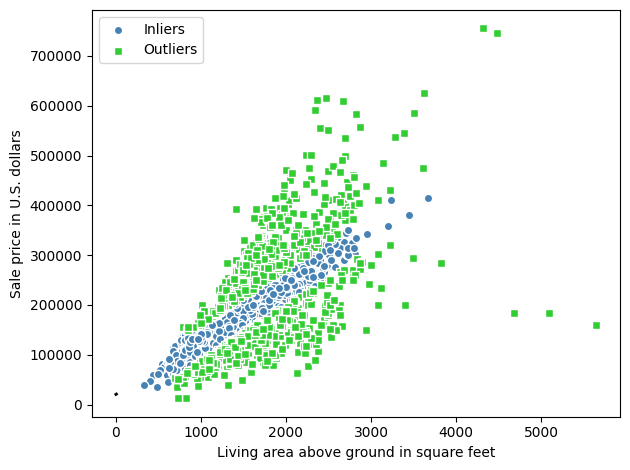

In [19]:
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)
line_X = np.arange(3,10,1)
line_y_ransac = ransac.predict(line_X[:, np.newaxis])
plt.scatter(X[inlier_mask], y[inlier_mask], c= 'steelblue', 
            edgecolors='white', marker='o', label= 'Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], c= 'limegreen', 
            edgecolors='white', marker='s', label= 'Outliers')
plt.plot(line_X, line_y_ransac, color = 'black', lw = 2)
plt.xlabel('Living area above ground in square feet')
plt.ylabel('Sale price in U.S. dollars')
plt.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

In [26]:
print(f'Slope: {ransac.estimator_.coef_[0][0]: .3f}')
print(f'Intercept: {ransac.estimator_.intercept_[0]: .3f}')

Slope:  106.348
Intercept:  20190.093


The MAD for this dataset can be calculated as 

In [28]:
def mean_absolute_deviation(data):
    return np.median(np.abs(data - np.mean(data)))
mean_absolute_deviation(y)

45930.81461249574